# Question 1: Watts-Strogatz Small World Network
> Team: Siddhant Bali (2022496) & Siddharth Bhaskar (2022498)

## Objective
To implement the Watts-Strogatz (WS) small-world network model and analyze how the network properties change with increasing rewiring probability (p).

We will compute and plot:
- Scaled Clustering Coefficient: C(p) / C(0)
- Scaled Characteristic Path Length: L(p) / L(0)

## Key Idea
The WS model transitions from:
- Regular Network → Small-World Network → Random Network

as rewiring probability (p) increases.

## Step 1: Import Required Libraries
We will use:
- NetworkX for graph generation
- NumPy for numerical operations
- Matplotlib for plotting

In [25]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

## Step 2: Parameter Selection

We choose parameters carefully as per assignment requirement:

- n = 1000 → sufficiently large network to observe realistic behavior
- k = 10 → each node connected to k nearest neighbors (k << n, ensures sparsity)
- p ∈ [0,1] → rewiring probability range:
  - p = 0 → regular lattice
  - 0 < p < 1 → small-world region
  - p = 1 → random network

We use logarithmic spacing for p to capture rapid transition.

In [26]:
num_nodes = 1000
neighbors_k = 10
rewiring_prob_min = 1e-4
rewiring_prob_max = 1.0
num_prob_points = 20
seed = 42

p_values = np.logspace(
    np.log10(rewiring_prob_min),
    np.log10(rewiring_prob_max),
    num_prob_points
)

## Step 3: Define Functions

We compute:
- Clustering coefficient (C)
- Characteristic path length (L)

For disconnected graphs:
- We take the largest connected component

In [27]:
def get_stats(G):
    # make sure graph is connected
    if not nx.is_connected(G):
        G = G.subgraph(max(nx.connected_components(G), key=len)).copy()

    C = nx.average_clustering(G)
    L = nx.average_shortest_path_length(G)

    return C, L

def make_ws(n, k, p, seed=None):
    return nx.watts_strogatz_graph(n, k, p, seed=seed)

def get_scaled_vals(p_values, n, k, C0, L0):
    C_scaled = []
    L_scaled = []

#     def make_ws(n, k, p, seed=None):
#     return nx.watts_strogatz_graph(n, k, p, seed=seed)

# def get_scaled_vals(p_values, n, k, C0, L0):
#     C_scaled = []
#     L_scaled = []

    for p in p_values:
        G = make_ws(n, k, p)
        C, L = get_stats(G)
        C_scaled.append(C / C0)
        L_scaled.append(L / L0)

    return C_scaled, L_scaled

def plot_it(p_values, C_scaled, L_scaled, title="Watts-Strogatz Small-World Network"):
    plt.figure(figsize=(8, 6))
    plt.plot(p_values, C_scaled, 'o-', label='C(p)/C(0)')
    plt.plot(p_values, L_scaled, 's-', label='L(p)/L(0)')
    plt.xscale('log')
    plt.xlabel("Rewiring Probability (p)")
    plt.ylabel("Scaled Values")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

## Step 4: Compute Baseline Metrics (p = 0)

This is a regular lattice network.
We will use it to normalize values.

In [28]:
G0 = make_ws(num_nodes, neighbors_k, 0, seed=seed)
C0, L0 = get_stats(G0)

print("Baseline Clustering (C0):", C0)
print("Baseline Path Length (L0):", L0)

Baseline Clustering (C0): 0.6666666666666666
Baseline Path Length (L0): 50.450450450450454


## Step 5: Compute Metrics for Different Rewiring Probabilities

We calculate:
- C(p) / C(0)
- L(p) / L(0)

In [29]:
C_scaled, L_scaled = get_scaled_vals(
    p_values, num_nodes, neighbors_k, C0, L0
)

## Step 6: Plot Results

We plot:
- C(p)/C(0)
- L(p)/L(0)

Note:
- X-axis is in log scale to match expected behavior

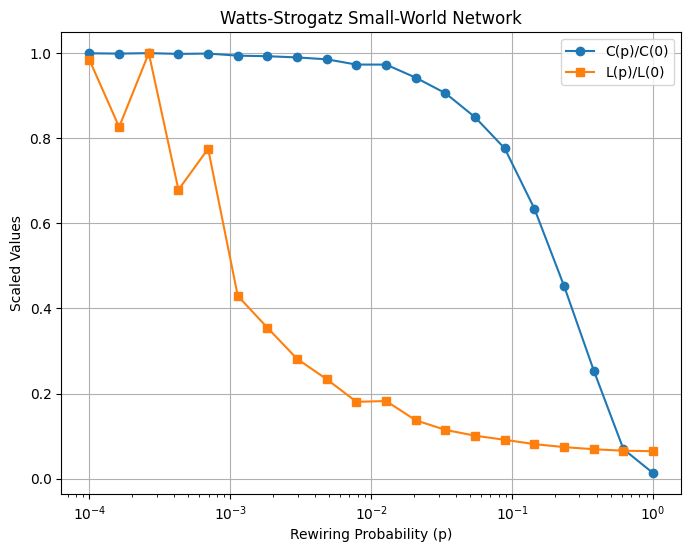

In [30]:
plot_it(p_values, C_scaled, L_scaled)

## Step 7: Observations

- At very small p:
  - High clustering
  - Large path length (regular network behavior)

- At intermediate p:
  - Path length drops rapidly
  - Clustering remains high → Small-world property

- At high p:
  - Both clustering and path length are low → Random network

## Conclusion

The Watts–Strogatz model demonstrates how a small amount of randomness leads to a network with both:
- High clustering
- Short path lengths

This explains the small-world phenomenon observed in real-world networks.